In [ ]:
!pip install lazypredict plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import urllib.request
import random
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px

In [ ]:
drive.mount('/content/drive')

ruta_final = "/content/drive/MyDrive/data_office_products.csv"
existe_final = os.path.exists(ruta_final)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
if not existe_final:
    url_reviews = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Office_Products.jsonl"
    ruta_reviews = "/content/drive/MyDrive/reviews_Office_Products.jsonl"

    if not os.path.exists(ruta_reviews):
        muestras = 500000
        cuotas = {"negativo": muestras, "neutro": muestras, "positivo": muestras}
        contadores = {"negativo": 0, "neutro": 0, "positivo": 0}

        solicitud = urllib.request.Request(url_reviews)
        with urllib.request.urlopen(solicitud) as respuesta, open(ruta_reviews, 'w', encoding='utf-8') as archivo_salida:
            for linea in respuesta:
                if all(contadores[c] >= cuotas[c] for c in cuotas):
                    break
                linea_decodificada = linea.decode('utf-8')
                try:
                    registro = json.loads(linea_decodificada)
                    rating = registro.get("rating", 0)
                    if rating <= 2: categoria = "negativo"
                    elif rating == 3.0: categoria = "neutro"
                    elif rating >= 4.0: categoria = "positivo"
                    else: continue

                    if contadores[categoria] < cuotas[categoria]:
                        archivo_salida.write(linea_decodificada)
                        contadores[categoria] += 1
                except json.JSONDecodeError:
                    continue

    url_meta = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Office_Products.jsonl"
    ruta_meta = "/content/drive/MyDrive/meta_Office_Products.jsonl"

    if not os.path.exists(ruta_meta):
        df_reviews = pd.read_json(ruta_reviews, lines=True)
        asins_unicos = set(df_reviews['parent_asin'].unique())

        solicitud = urllib.request.Request(url_meta)
        with urllib.request.urlopen(solicitud) as respuesta, open(ruta_meta, 'w', encoding='utf-8') as archivo_salida:
            for linea in respuesta:
                linea_decodificada = linea.decode('utf-8')
                try:
                    registro = json.loads(linea_decodificada)
                    if registro.get("parent_asin") in asins_unicos:
                        archivo_salida.write(linea_decodificada)
                except json.JSONDecodeError:
                    continue

In [ ]:
if not existe_final:
    df_reviews = pd.read_json(ruta_reviews, lines=True)
    df_meta = pd.read_json(ruta_meta, lines=True)

    df_master = pd.merge(df_reviews, df_meta, on="parent_asin", how="inner", suffixes=('_usuario', '_catalogo'))

    borrar = [
        'images_usuario', 'images_catalogo', 'videos', 'timestamp',
        'user_id', 'bought_together', 'subtitle', 'author',
        'features', 'description', 'details', 'store', 'asin', 'main_category'
    ]
    df_master.drop(columns=[col for col in borrar if col in df_master.columns], inplace=True)
    df_master.dropna(subset=['text'], inplace=True)

    df_master['price'] = df_master['price'].astype(str)
    df_master['price'] = df_master['price'].str.replace(r'[^\d.]', '', regex=True)
    df_master['price'] = pd.to_numeric(df_master['price'], errors='coerce')
    df_master['price'] = df_master['price'].fillna(df_master['price'].median())

    def categorizar_satisfaccion(rating):
        if rating <= 2: return 0
        elif rating == 3: return 1
        else: return 2

    df_master['target'] = df_master['rating'].apply(categorizar_satisfaccion)
    df_master.drop(columns='rating', inplace=True)

    df_master['review_length'] = df_master['text'].astype(str).apply(len)
    df_master['word_count'] = df_master['text'].astype(str).apply(lambda x: len(x.split()))
    df_master['exclamation_count'] = df_master['text'].astype(str).apply(lambda x: x.count('!'))

    df_master.to_csv(ruta_final, index=False)

In [ ]:
df_master = pd.read_csv(ruta_final)

In [ ]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 14 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   title_usuario      1499734 non-null  object 
 1   text               1499772 non-null  object 
 2   parent_asin        1500000 non-null  object 
 3   helpful_vote       1500000 non-null  int64  
 4   verified_purchase  1500000 non-null  bool   
 5   title_catalogo     1499910 non-null  object 
 6   average_rating     1500000 non-null  float64
 7   rating_number      1500000 non-null  int64  
 8   price              1500000 non-null  float64
 9   categories         1500000 non-null  object 
 10  target             1500000 non-null  int64  
 11  review_length      1500000 non-null  int64  
 12  word_count         1500000 non-null  int64  
 13  exclamation_count  1500000 non-null  int64  
dtypes: bool(1), float64(2), int64(6), object(5)
memory usage: 150.2+ MB


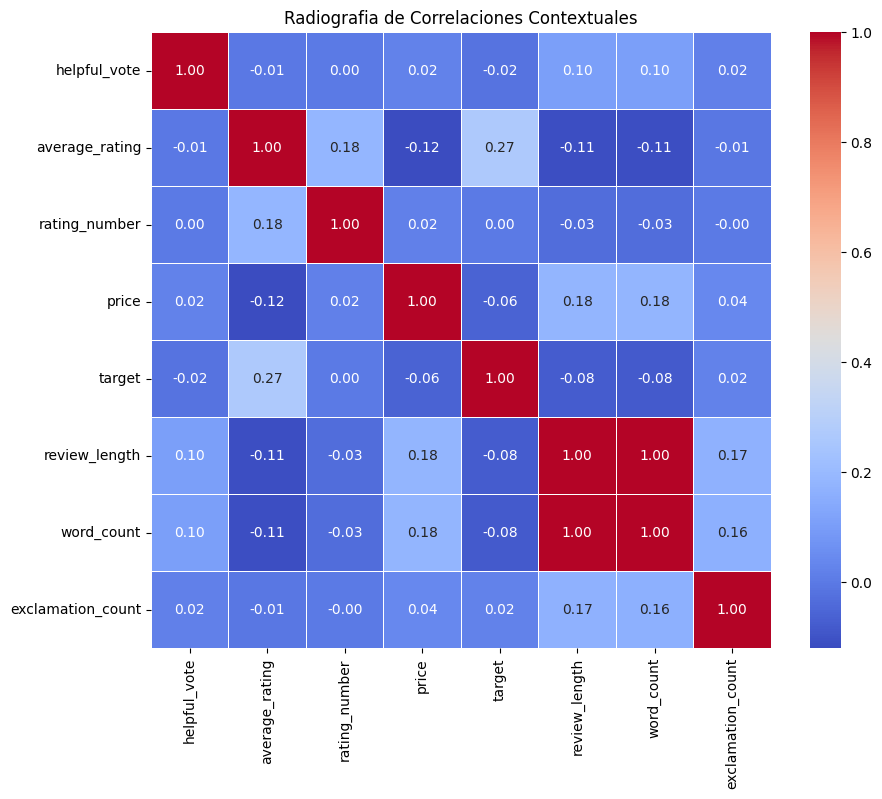

In [ ]:
plt.figure(figsize=(10, 8))
columnas_numericas = df_master.select_dtypes(include=['number']).columns.tolist()
matriz_correlacion = df_master[columnas_numericas].corr()

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de correlaciones entre variables')
plt.show()

/tmp/ipykernel_8691/2833409358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_master, x='target', y='word_count', palette='viridis')
/tmp/ipykernel_8691/2833409358.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_master, x='target', y='price', palette='viridis')


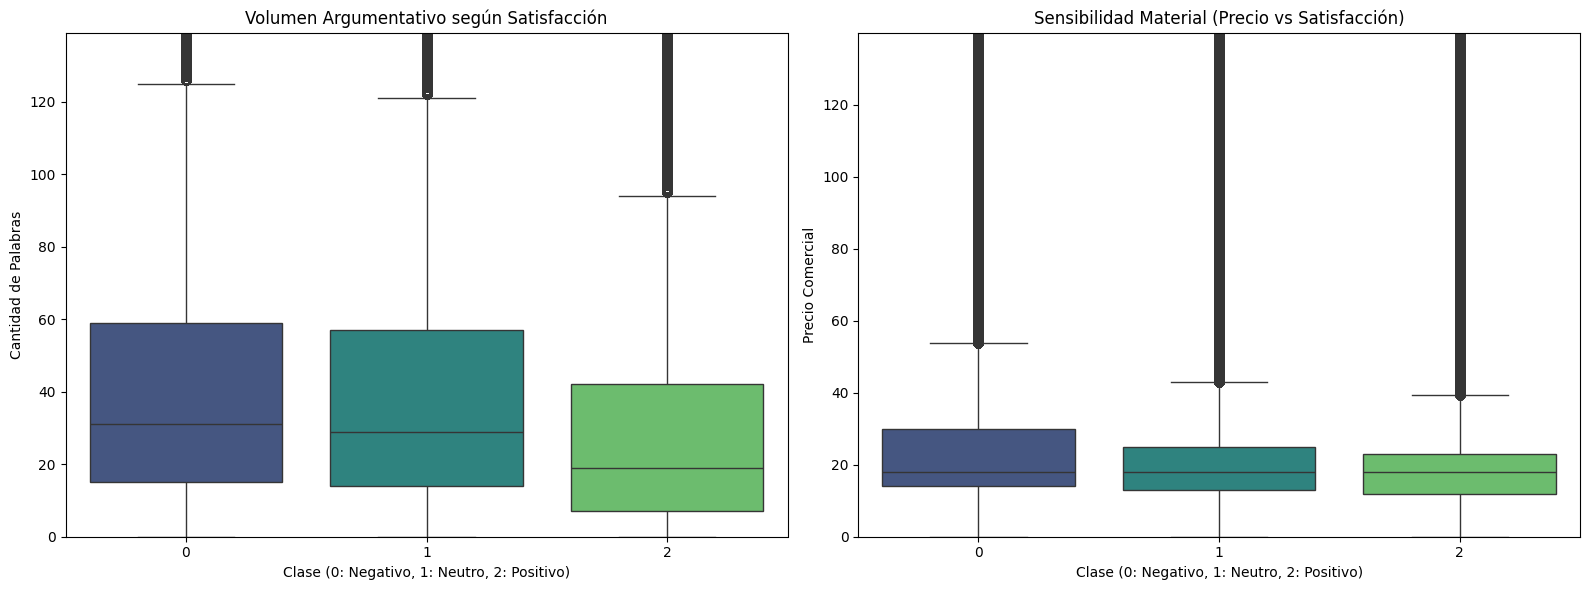

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], data=df_master, x='target', y='word_count', palette='viridis')
axes[0].set_title('Volumen Argumentativo según Satisfacción')
axes[0].set_xlabel('Clase (0: Negativo, 1: Neutro, 2: Positivo)')
axes[0].set_ylabel('Cantidad de Palabras')
axes[0].set_ylim(0, df_master['word_count'].quantile(0.95))

sns.boxplot(ax=axes[1], data=df_master, x='target', y='price', palette='viridis')
axes[1].set_title('Sensibilidad Material (Precio vs Satisfacción)')
axes[1].set_xlabel('Clase (0: Negativo, 1: Neutro, 2: Positivo)')
axes[1].set_ylabel('Precio Comercial')
axes[1].set_ylim(0, df_master['price'].quantile(0.95))

plt.tight_layout()
plt.show()

# Clustering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

In [ ]:
df_muestra_cluster = df_master.sample(n=5000, random_state=42).reset_index(drop=True)

vectorizador_cluster = TfidfVectorizer(max_features=1500, stop_words='english')
matriz_tfidf_cluster = vectorizador_cluster.fit_transform(df_muestra_cluster['text'].fillna(''))

svd = TruncatedSVD(n_components=3, random_state=42)
matriz_3d = svd.fit_transform(matriz_tfidf_cluster)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(matriz_3d)

df_muestra_cluster['cluster'] = clusters.astype(str)
df_muestra_cluster['eje_x'] = matriz_3d[:, 0]
df_muestra_cluster['eje_y'] = matriz_3d[:, 1]
df_muestra_cluster['eje_z'] = matriz_3d[:, 2]

fig_3d = px.scatter_3d(
    df_muestra_cluster,
    x='eje_x',
    y='eje_y',
    z='eje_z',
    color='cluster',
    hover_data=['price', 'target', 'title_catalogo'],
    title="Topografía de Reseñas: Proyección SVD y Segmentación K-Means",
    opacity=0.7,
    height=800
)

fig_3d.update_traces(marker=dict(size=3))
fig_3d.show()